In [223]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
import re
from Bio import PDB
from Bio.PDB import PDBParser



In [224]:
'''Step 1: Counting n-neighbours for atoms'''

def convert_cif_to_pdb(cif_file_path, pdb_file_path):
    '''
    Takes in a .cif file, and returns a .pdb file.

    Both file paths should be specified below    
    '''

    parser = PDB.MMCIFParser()
    structure = parser.get_structure('protein', cif_file_path)

    io = PDB.PDBIO()
    io.set_structure(structure)
    io.save(pdb_file_path)

def extract_pdb_info(pdb_file_path):
    """
    Reads a PDB file and extracts 3D spatial coordinates and amino acids.

    Input: pdb_file_path (str): Path to the PDB file.

    Output:  A list of dictionaries, each containing information about each atom.
    """
    # Create a PDBParser object
    parser = PDBParser(PERMISSIVE=1)
    
    # Parse the structure from the PDB file
    structure = parser.get_structure('protein', pdb_file_path)
    
    # List to hold the extracted information
    atom_info_list = []

    # Extract information from the structure
    for model in structure:
        for chain in model:
            for residue in chain:
                for atom in residue:
                    atom_info = {
                        'model_id': model.id,
                        'chain_id': chain.id,
                        'residue_name': residue.resname,
                        'residue_id': residue.id[1],
                        'atom_name': atom.name,
                        'atom_coords': atom.coord.tolist()
                    }
                    atom_info_list.append(atom_info)

    return atom_info_list


def count_neighboring_atoms(data):
    '''
    Adds 'neighbour_count': n for each atom data dictionary

    Input: A list of dictionaries, each containing information about each atom.
    
    Output: The same list of dictionaries, appended with 'neighbour_count': n for each atom data dictionary
    '''

    def distance_np(coord1, coord2):
        return np.linalg.norm(coord1 - coord2)

    def atom_nearest_neighbours(data):

        coords = np.array([atom['atom_coords'] for atom in data])
        neighbour_counts = np.zeros(len(data), dtype=int)
        
        for i in range(len(coords)):
            for j in range(i+1, len(coords)):
                distances = distance_np(coords[i],coords[j])
                if distances <= 3:
                    neighbour_counts[i] += 1

        for i in range(len(neighbour_counts)):
            data[i]['neighbour_count'] = neighbour_counts[i]
        # print(neighbour_counts)
        
        return data

    neighbour_counts = atom_nearest_neighbours(data)

    '''
    #delete irrelevant ids in data if required at this step.
    for entry in range(len(neighbour_counts)):
        del neighbour_counts[entry]['model_id']
        del neighbour_counts[entry]['chain_id']
        # del neighbour_counts[entry]['residue_name']
        del neighbour_counts[entry]['residue_id']
    '''
        
    return neighbour_counts

In [225]:
'''Step 2: Counting n-neighbours for amino acids'''

def count_neighbouring_amino_acids(data):
    '''
    Trim atom dictionary to retain one entry per amino acid with the highest neighbour_count

    Takes in dictionary of atom data appended with key-value pair 'neighbour_count': n  

    Returns dictionary of amino acids with key-value pair 'neighbour_count': n 
    '''

    # Dictionary to store the highest 'neighbour_count' for each 'residue_id'
    max_neighbour_counts = {}

    # Iterate through the data to find the highest 'neighbour_count' for each 'residue_id'
    for atom in data:
        residue_id = atom['residue_id']
        neighbour_count = atom.get('neighbour_count', 0)
        if residue_id not in max_neighbour_counts or neighbour_count > max_neighbour_counts[residue_id]:
            max_neighbour_counts[residue_id] = neighbour_count

    # Filter the original data to retain only one entry for each 'residue_id' with the highest 'neighbour_count'
    filtered_data = []
    for atom in data:
        residue_id = atom['residue_id']
        neighbour_count = atom.get('neighbour_count', 0)
        if neighbour_count == max_neighbour_counts[residue_id]:
            # Remove other entries for the same residue_id
            filtered_data = [entry for entry in filtered_data if entry['residue_id'] != residue_id]
            filtered_data.append(atom)
            atom.pop('model_id')
            atom.pop('atom_name')
            atom.pop('atom_coords')

    return filtered_data

def amino_acid_vector(amino_acid_info_count):
    result = []
    for amino_acid in amino_acid_info_count:
        entry = [f"{amino_acid['residue_name']}_{amino_acid['residue_id']}", amino_acid['neighbour_count']]
        result.append(entry)
    return result

In [226]:
def pdb_to_n_neighbour_vector(pdb_file_path):
    '''Step 1: Counting n-neighbours for atoms'''
        # convert_cif_to_pdb(cif_file_path, pdb_file_path)
    amino_vector = []

    atom_info_list = extract_pdb_info(pdb_file_path)
    print(len(atom_info_list))

    num_atom_entries = 100 #Adjust this, total is 7714 atoms
    atom_info_count = count_neighboring_atoms(atom_info_list[:])

    '''
    #Check loading
    for atom_info in atom_info_count[:5]:
        print(atom_info)
    '''

    '''Step 2: Counting n-neighbours for amino acids'''
    amino_acid_info_count = count_neighbouring_amino_acids(atom_info_count)

    '''
    #Check amino_acid_neighbour, should have 1389
    num_amino_acid_entries = 20 #Adjust this
    for amino_acid in amino_acid_info_count[:num_amino_acid_entries]:  
        print(f"{amino_acid}")
    '''

    print(f"Number of Amino Acids: {len(amino_acid_info_count)}")

    '''Step 3: Return [amino acid, n-neighbours] 2D vector'''
    indiv_amino_vector = amino_acid_vector(amino_acid_info_count)
    print(indiv_amino_vector)

    for amino_acid in indiv_amino_vector:
        amino_vector.append(amino_acid)

    with open('20-amino-vector-unmerged', 'a') as f:
        f.write(str(amino_vector))

    result_queue.put(amino_vector)

    return(amino_vector)

In [227]:
def merge_amino_vector(residues):
    # Use a dictionary to store the highest value for each residue
    residue_dict = {}
    
    for residue in residues:
        name, count = residue
        if name in residue_dict:
            if count > residue_dict[name]:
                residue_dict[name] = count
        else:
            residue_dict[name] = count

    # Convert the dictionary back to a list of lists
    result = [[name, count] for name, count in residue_dict.items()]
    
    # Sort the list by residue_id in ascending order
    result.sort(key=lambda x: int(x[0].split('_')[1]))
    
    return result

def plot_residues(df):
    plt.figure(figsize=(15, 8))  # Set the figure size
    plt.bar(df['Residue'], df['Neighbour_Count'], color='skyblue')
    plt.xlabel('Residue')
    plt.ylabel('Neighbour Count')
    plt.title('Residue Neighbour Count')
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
    plt.tight_layout()  # Adjust layout to fit x-axis labels
    plt.show()

In [228]:
cif_file_path = './7sfc_updated.cif'
pdb_file_path = ['./pdb/pdb3epz.pdb', './pdb/pdb3pta.pdb', './pdb/pdb3swr.pdb', './pdb/pdb4wxx.pdb',
                 './pdb/pdb4yoc.pdb', './pdb/pdb4z96.pdb', './pdb/pdb4z97.pdb', './pdb/pdb5wvo.pdb',
                 './pdb/pdb5ydr.pdb', './pdb/pdb6k3a.pdb', './pdb/pdb6l1f.pdb', './pdb/pdb6x9i.pdb',
                 './pdb/pdb6x9j.pdb', './pdb/pdb6x9k.pdb', './pdb/pdb7sfc.pdb', './pdb/pdb7sfe.pdb',
                 './pdb/pdb7sff.pdb', './pdb/pdb7sfg.pdb', './pdb/pdb8v9u.pdb', './pdb/AF-P26358-F1-model_v4.pdb']

# ============== MAIN =======================

#pdb_file_path1 = ['./pdb/AF-P26358-F1-model_v4.pdb']
#pdb_file_path2 = ['./pdb/pdb7sfe.pdb']
#pdb_file_path3 = ['./pdb/pdb7sff.pdb']
#pdb_file_path4 = ['./pdb/pdb7sfg.pdb']
#pdb_file_path5 = ['./pdb/pdb8v9u.pdb']
#pdb_file_path6 = ['./pdb/pdb8v9u.pdb']
#pdb_file_path7 = ['./pdb/pdb8v9u.pdb']
#pdb_file_path8 = ['./pdb/pdb6x9k.pdb']


import threading
from queue import Queue
import os

result_queue = Queue()

thread1 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[0],))
thread2 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[1],))
thread3 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[2],))
thread4 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[3],))
thread5 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[4],))
thread6 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[5],))
thread7 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[6],))
thread8 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[7],))
thread9 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[8],))
thread10 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[9],))
thread11 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[10],))
thread12 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[11],))
thread13 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[12],))
thread14 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[13],))
thread15 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[14],))
thread16 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[15],))
thread17 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[16],))
thread18 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[17],))
thread19 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[18],))
thread20 = threading.Thread(target=pdb_to_n_neighbour_vector, args=(pdb_file_path[19],))



thread1.start()
thread2.start()
thread3.start()
thread4.start()
thread5.start()
thread6.start()
thread7.start()
thread8.start()
thread9.start()
thread10.start()
thread11.start()
thread12.start()
thread13.start()
thread14.start()
thread15.start()
thread16.start()
thread17.start()
thread18.start()
thread19.start()
thread20.start()

thread1.join()
thread2.join()
thread3.join()
thread4.join()
thread5.join()
thread6.join()
thread7.join()
thread8.join()
thread9.join()
thread10.join()
thread11.join()
thread12.join()
thread13.join()
thread14.join()
thread15.join()
thread16.join()
thread17.join()
thread18.join()
thread19.join()
thread20.join()

result = result_queue.get()
print(type(result))
print(result)

with open('20-amino-vector', 'w') as f:
    f.write(str(result))

#print(thread1)
#print(thread2)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8012.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 8032.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8033.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 8100.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 8646.
  warnings.w

3550
7989
3339
667


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 3605.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 3610.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 3616.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 3641.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 3844.
  warnings.w

3334
4097
5671
4094
7907
7714
7277
7130
7461
7255
6956


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 14866.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 14886.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 14952.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 14956.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:89: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 14988.
  warni

11381
7383
19035
12862
40590
Number of Amino Acids: 105
[['ARG_140', 5], ['SER_141', 5], ['MLZ_142', 5], ['SER_143', 5], ['ASP_144', 6], ['GLY_145', 2], ['HIS_3', 5], ['MET_4', 6], ['PRO_5', 7], ['PRO_6', 6], ['ASN_7', 6], ['ARG_8', 6], ['PRO_9', 6], ['GLY_10', 3], ['ILE_11', 6], ['THR_12', 6], ['PHE_13', 5], ['GLU_14', 6], ['ILE_15', 6], ['GLY_16', 4], ['ALA_17', 4], ['ARG_18', 5], ['LEU_19', 5], ['GLU_20', 5], ['ALA_21', 5], ['LEU_22', 5], ['ASP_23', 6], ['TYR_24', 5], ['LEU_25', 6], ['GLN_26', 5], ['LYS_27', 5], ['TRP_28', 6], ['TYR_29', 6], ['PRO_30', 6], ['SER_31', 5], ['ARG_32', 5], ['ILE_33', 6], ['GLU_34', 5], ['LYS_35', 5], ['ILE_36', 6], ['ASP_37', 6], ['TYR_38', 5], ['GLU_39', 4], ['GLU_40', 5], ['GLY_41', 3], ['LYS_42', 5], ['MET_43', 6], ['LEU_44', 5], ['VAL_45', 6], ['HIS_46', 5], ['PHE_47', 6], ['GLU_48', 5], ['ARG_49', 5], ['TRP_50', 6], ['SER_51', 5], ['HIS_52', 5], ['ARG_53', 5], ['TYR_54', 5], ['ASP_55', 6], ['GLU_56', 5], ['TRP_57', 6], ['ILE_58', 6], ['TYR_59', 5],

In [180]:
amino_vectors = pdb_to_n_neighbour_vector()
print(amino_vectos)

TypeError: pdb_to_n_neighbour_vector() missing 1 required positional argument: 'pdb_file_path'

In [177]:
print(type(thread1))

amino_vector1 = [entry for entry in thread1]
print(type(amino_vector1))
print(amino_vector1)
# amino_vector = thread1

'''
#Store merged_amino_vector in a file
with open('amino_vector', 'a') as f:
    f.write(str(amino_vector))
'''

<class 'threading.Thread'>


TypeError: 'Thread' object is not iterable

In [222]:
with open('amino_vector', 'r') as f:
    amino_vector_string = f.read()
    elements = re.findall(r'\[.*?\]|\w+', amino_vector_string)
    output_list = [eval(element) if element.startswith('[') else element for element in elements]

    print(len(output_list))
    print(output_list)


SyntaxError: '[' was never closed (<string>, line 1)

       Residue  Neighbour_Count
0         NA_1                0
1         DT_1                6
2        SO4_1                4
3        HOH_2                0
4         DC_2                7
...        ...              ...
1929  HOH_2122                0
1930  HOH_2123                1
1931  HOH_2124                0
1932  HOH_2125                0
1933  HOH_2126                0

[1934 rows x 2 columns]
(1934, 2)


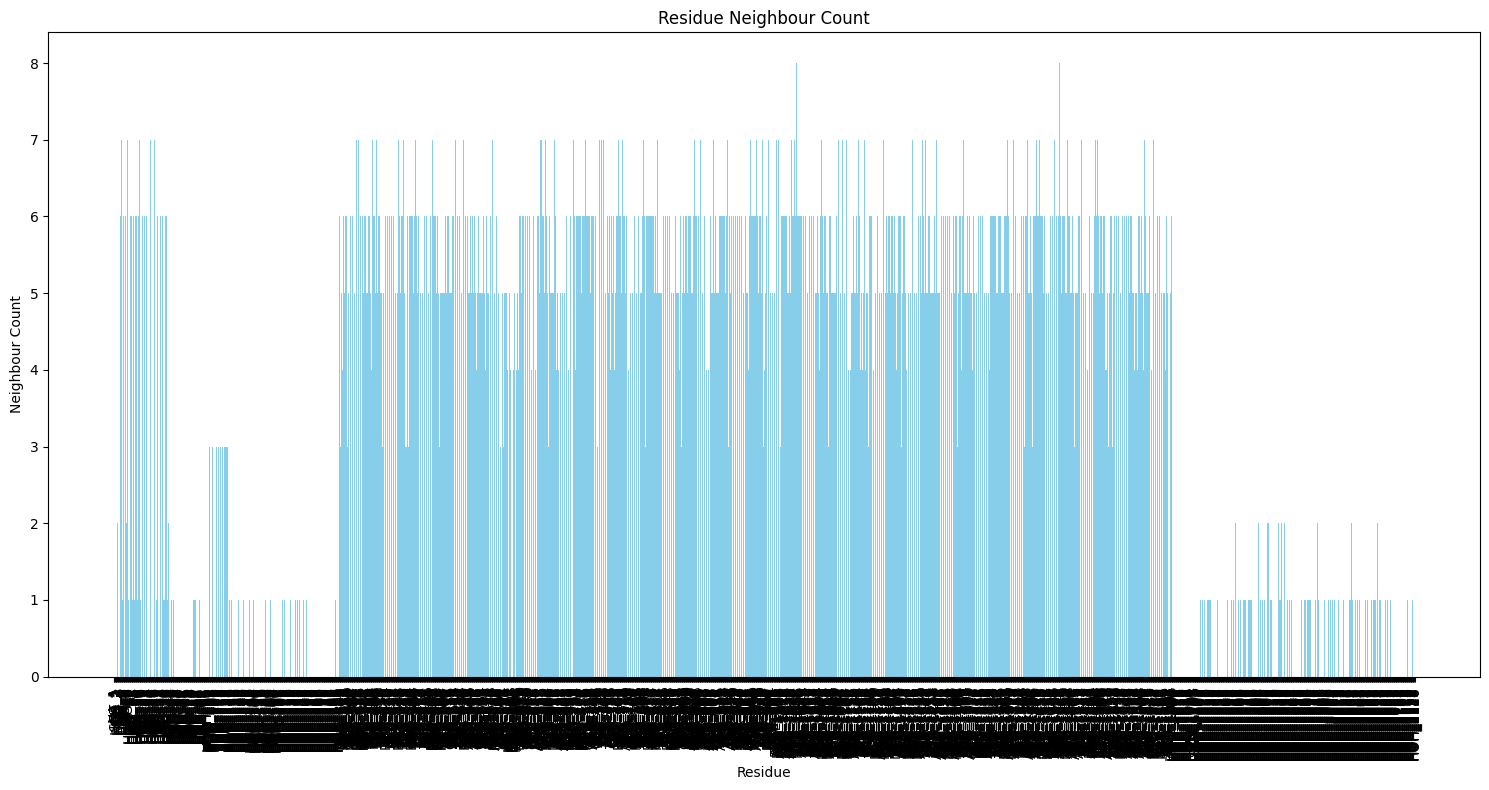

In [164]:
with open('20-amino-vector-unmerged', 'r') as f:
    amino_vector = list(f.read())
    merged_amino_vector = merge_amino_vector(amino_vector)
    
    with open('20-amino-vector', 'a') as g:
        g.write(merged_amino_vector)

amino_df = pd.DataFrame(merged_amino_vector, columns=['Residue', 'Neighbour_Count'])
print(amino_df)
print(amino_df.shape)
# amino_df.to_csv('DNMT1-complete.csv', index=False)

# plot_residues(amino_df)


In [ ]:
# Function to display most connected atoms onto PDB view
